# AIG 100 Project 03
Collin Joseph <br>
137672259

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 

## Dataset & Task
For this project I will be using the [CDC Diabetes Health Indicators](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators) from the UCI Machine Learning Repository.<br>
This dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes.<br>
The [BRFSS Codebook](https://www.cdc.gov/brfss/annual_data/2014/pdf/CODEBOOK14_LLCP.pdf) contains additional information about what the integer or binary values represent. <br>
The **target variable** for this dataset a binary variable representing the diagnosis. Specifically whether each person reprsented in the dataset was diabetic or pre-diabetic. <br>
I will attempt to use a Random Forest model to solve this **classification** task. <br>
The dataset contains many binary, integer or categorical variables. <br>
These kinds of features lend themselves intuitively to a tree structure and will likely produce models with higher explainability than might be possible with other models like neural networks.

In [27]:
# fetch dataset 
dataset = fetch_ucirepo(id=891) 
  
# data (as pandas dataframes) 
X = dataset.data.features 
y = dataset.data.targets 
  
# variable information 
print(dataset.variables) 

                    name     role     type      demographic  \
0                     ID       ID  Integer             None   
1        Diabetes_binary   Target   Binary             None   
2                 HighBP  Feature   Binary             None   
3               HighChol  Feature   Binary             None   
4              CholCheck  Feature   Binary             None   
5                    BMI  Feature  Integer             None   
6                 Smoker  Feature   Binary             None   
7                 Stroke  Feature   Binary             None   
8   HeartDiseaseorAttack  Feature   Binary             None   
9           PhysActivity  Feature   Binary             None   
10                Fruits  Feature   Binary             None   
11               Veggies  Feature   Binary             None   
12     HvyAlcoholConsump  Feature   Binary             None   
13         AnyHealthcare  Feature   Binary             None   
14           NoDocbcCost  Feature   Binary             

In [28]:
# Check class balance
y.value_counts(normalize=True)

Diabetes_binary
0                  0.860667
1                  0.139333
Name: proportion, dtype: float64

I note that there is a significant class imbalance as is often the case with disease diagnosis.

## Preprocessing

### Missing Values

In [29]:
# Check for missing values
X.isna().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [30]:
y.isna().sum()

Diabetes_binary    0
dtype: int64

This dataset is not missing any values.

### Outliers
Most features are on a fixed, finite scale so outliers within these columns would be unlikely or have limited meaning.<br>
The BMI column is not explicitly restricted to any scale so I will investigate it's distribution.

In [31]:

X["BMI"].describe()

count    253680.000000
mean         28.382364
std           6.608694
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          98.000000
Name: BMI, dtype: float64

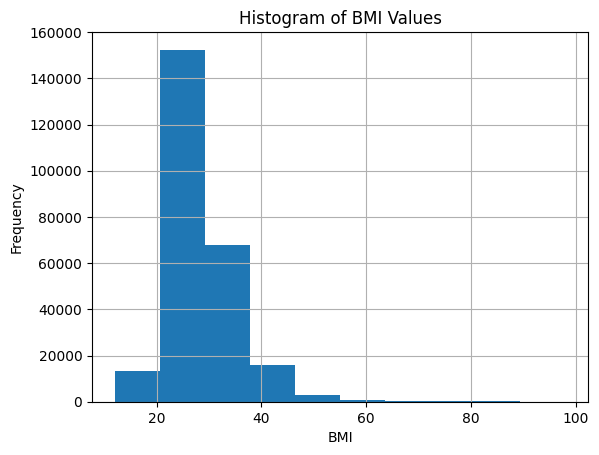

In [32]:
# Histogram of BMI
plt.hist(X["BMI"])
plt.title("Histogram of BMI Values")
plt.ylabel("Frequency")
plt.xlabel("BMI")
plt.grid(True)

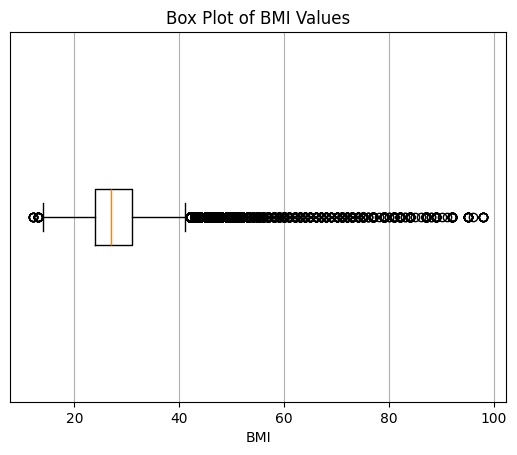

In [33]:
# Box Plot of BMI
plt.boxplot(X["BMI"], vert=False)
plt.title("Box Plot of BMI Values")
plt.yticks([])
plt.xlabel("BMI")
plt.grid(axis="x")


The BMI feature clearly has a large positive (right) skew with a significant portion of outliers.<br>
Random forest models are robust to outliers so these values are unlikely to prevent good generalization. <br>
In addition, if BMI is a strong indicator of diabetes diagnosis, it is useful to keep these observations so that people in this BMI range are represened in the final model. <br>
Therefore, we keep these outliers.

### Scaling
Since I am using a random forest model, there is no need to scale feature values.

## Model Implementation

First, the data is split into train and test sets. <br>
Since there is plenty of data, I selected a 70-30% ratio for train-test. <br>
Since the dataset has a significant class imbalance the spliting is stratified.

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, stratify=y)

### Hyperparameter Search
A grid search is conducted using **F1 score** as the selection criterion.

In [ ]:
# hyper parameter grid search
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':   [100, 200, 300], # number of trees in forest
    'max_depth':      [30, 50, None], # maximum tree depth
    'max_features':   ['sqrt', None], # maximum features to consider per split
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced"),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, np.ravel(y_train));

print(grid_search.best_params_)
print(grid_search.best_score_)

model = grid_search.best_estimator_

Fitting 3 folds for each of 18 candidates, totalling 54 fits


c:\Users\aaron\anaconda3\envs\AIG-General\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'max_depth': 30, 'max_features': None, 'n_estimators': 100}
0.23463208280573689


## Evaluation
Since there is a significant class imbalance simply using accuracy to evaluate could be misleading. <br>
I will evaluate the candidate model using: 
- Precision 
- Recall 
- F1 Score 
- Receiver operating characteristic (ROC)

In [36]:
y_score = model.predict_proba(X_test)
y_pred = model.predict(X_test)

In [37]:
# Precision, Recall and F1 Score
from sklearn.metrics import precision_recall_fscore_support
prc, rec, f1, _ = precision_recall_fscore_support(y_pred=y_pred, y_true=y_test)
print((" "*15) + "y=0" + (" "*10) + "y=1")
print(f"Precision: {prc}")
print(f"Recall   : {rec}")
print(f"F1 Score : {f1}")

               y=0          y=1
Precision: [0.87685625 0.42740741]
Recall   : [0.96459542 0.16324029]
F1 Score : [0.91863559 0.23624949]


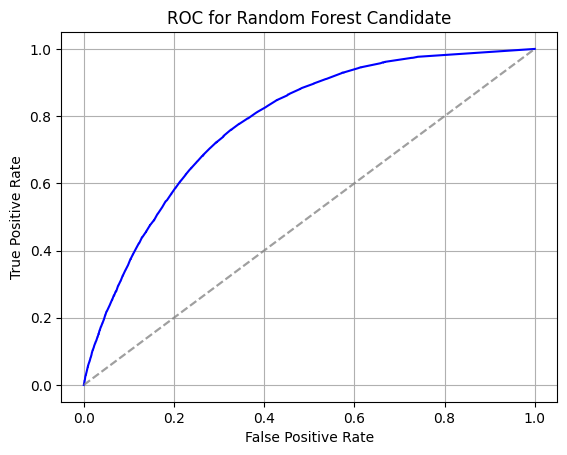

In [38]:
# ROC
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_score=y_score[:,1], y_true=y_test);

# Plot curve
plt.plot(fpr, tpr, "b-")
plt.plot([[0,0],[1,1]], "--", color="grey", alpha=0.5) # random guess line
plt.title("ROC for Random Forest Candidate")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)

In [39]:
# ROC-AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_score=y_score[:,1], y_true=y_test)
print(f"ROC-AUC: {auc}")

ROC-AUC: 0.7814945202876057


## Interpretation
The results show a bit of a contradiction on the surface.<br>
The model yielded very poor precision and recall (and consequently f1 score) on the positive class (positive diabetes diagnosis). The F1 score was `0.24` for the positive class. <br>
Specifically, the precision of `0.43` indicates that the model only correctly predicted a positive diagnosis `43%` of the time, and the recall of `0.16` indicates the model only detected positive diagnoses `16%` of the time.<br>
However, the ROC AUC score of `0.78` suggests that the model was able to learn some useful pattern from the data. <br>
The key difference is that the receiver operating characteristic considers a variety of decision thresholds for the positive class while the precision and recall was computed based on a `0.5` threshold (the predicted binary class is the one with the highest mean probability across trees in the forest).<br>
These results suggests that using a confidence threshold lower than `0.5` to predict the a positive outcome would yeild better results.

To find the best threshold, I compare F1 scores for the positive class across a variety of threshold values:

In [40]:
from sklearn.metrics import precision_recall_curve

prcs, recs, thrs = precision_recall_curve(y_test, y_score[:, 1])
f1_scores        = 2 * (prcs * recs) / (prcs + recs)

best_idx         = np.argmax(f1_scores)
best_threshold   = thrs[best_idx]

print(f"Precision     : {prcs[best_idx]:.2f}")
print(f"Recall        : {recs[best_idx]:.2f}")
print(f"F1            : {f1_scores[best_idx]:.2f}")
print(f"Best threshold: {best_threshold:.2f}")

Precision     : 0.31
Recall        : 0.64
F1            : 0.41
Best threshold: 0.20


Using a threshold of `0.2` yeilds an F1 score `0.41` which is an improvement over `0.24` observed when the threshold was `0.5`.<br>
However, these are still not particularly good results. <br>
One explanation for this could be that there are confounding variables that are not accounted for in the features included in this dataset. <br>
Genetic disposition might be one such variable.

## Real-world Implication

This dataset was collected from surveys about people's lifestyle and health statistics. <br>
A model like this one with an appropriatly linient threshold like `0.2` could be used to flag responses to the survey as at high risk of diabetes which could be helpful to the people answering the survey. <br>
It could act as a suggestion to adjust aspects of their lifestyle or seek medical/health expert advice even if they are not already diabetic or haven't yet been tested for diabetes.

## Reflection

Obtaining good results from this dataset was surprisingly difficult. I obtained results of a similar quality using a multi-layer perceptron on min-max scaled features and using a single decision tree. <br>
The results of this project highlight the importance of dataset quality on the predictive performance of models. Imbalanced datasets and datasets missing important features are significantly more difficult to extract useful patterns from.